In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Load 2019 data for EDA (faster, focused)
df = pd.read_csv('../data/processed/delhi_2019_all_stations.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Add time features
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek  # 0=Monday
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Summer', 4: 'Summer', 5: 'Summer',
    6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
    10: 'Post-Monsoon', 11: 'Post-Monsoon'
})

print("Shape:", df.shape)
print("Stations:", df['Station'].nunique())
print("Date range:", df['Timestamp'].min(), "→", df['Timestamp'].max())
df.head(3)

Shape: (1366560, 33)
Stations: 37
Date range: 2019-01-01 00:00:00 → 2019-12-31 23:45:00


,Timestamp,PM25,PM10,NO,NO2,NOx,NH3,SO2,CO,Ozone,...,BP,VWS,Station,Year,Source_file,Hour,Day,Month,DayOfWeek,Season
0,2019-01-01 00:00:00,338.0,512.0,96.1,145.1,155.6,60.4,17.7,3.8,1.2,...,997.8,NaN,Alipur,2019,Raw_data_15Min_2019_site_5024_Alipur_Delhi_DPC...,0,1,1,1,Winter
1,2019-01-01 00:15:00,338.0,512.0,124.6,165.1,189.2,63.2,17.7,4.8,1.8,...,997.7,NaN,Alipur,2019,Raw_data_15Min_2019_site_5024_Alipur_Delhi_DPC...,0,1,1,1,Winter
2,2019-01-01 00:30:00,385.0,539.0,126.7,170.0,193.5,64.4,18.5,3.6,1.3,...,997.6,NaN,Alipur,2019,Raw_data_15Min_2019_site_5024_Alipur_Delhi_DPC...,0,1,1,1,Winter


In [2]:
pollutants = ['PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 
              'CO', 'Ozone', 'Benzene', 'Toluene', 'Xylene']

stats = df[pollutants].describe().T
stats['skewness'] = df[pollutants].skew()
stats['kurtosis'] = df[pollutants].kurt()
stats = stats.round(2)

print("=== DESCRIPTIVE STATISTICS ===")
stats

=== DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
PM25,1215921.0,109.31,104.94,0.04,41.00,74.00,140.00,1000.00,2.34,7.91
PM10,1113765.0,216.31,155.79,0.06,103.00,177.00,287.00,1000.00,1.48,2.69
NO,1188048.0,31.22,58.60,0.01,3.30,8.55,29.84,500.00,3.67,16.48
NO2,1203610.0,44.76,36.26,0.01,20.60,35.10,58.60,499.83,2.49,12.52
NOx,1206933.0,52.13,61.82,0.00,16.90,30.68,60.60,500.00,3.03,11.67
NH3,883576.0,36.43,22.29,0.01,22.77,32.00,44.80,495.30,3.21,28.52
SO2,950669.0,14.12,11.33,0.01,7.20,11.50,17.70,199.60,3.13,20.57
CO,1157557.0,1.37,1.15,0.00,0.69,1.10,1.70,44.79,3.13,30.69
Ozone,1159482.0,33.12,35.85,0.01,8.50,19.50,44.30,200.00,1.85,3.41
Benzene,969964.0,3.66,4.56,0.00,0.80,2.40,4.88,344.20,4.50,86.72


<Figure size 1400x600 with 0 Axes>

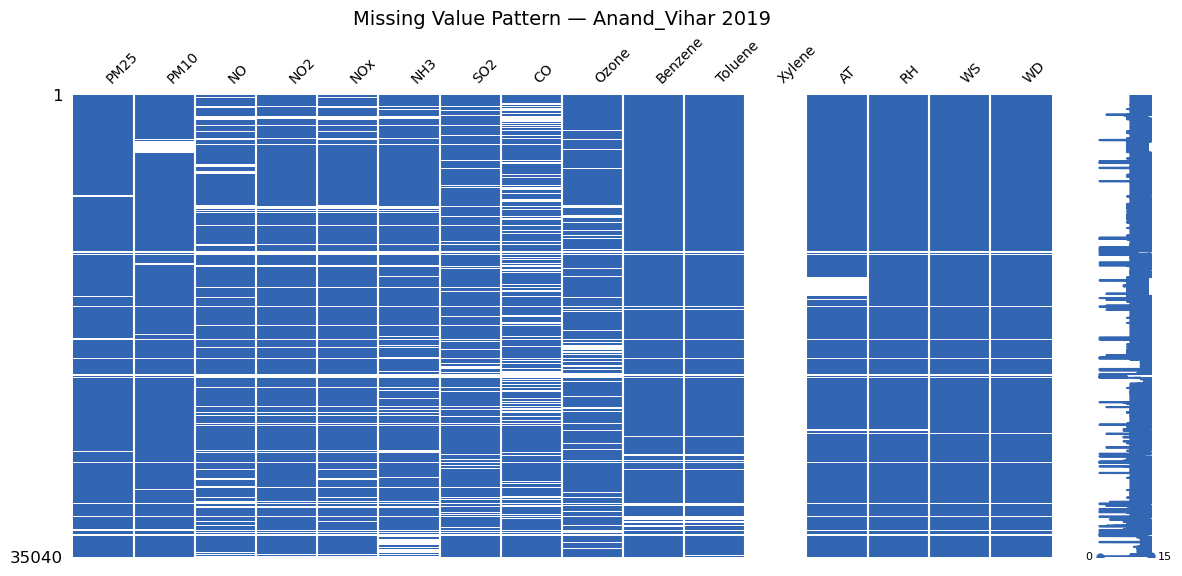

Saved!


In [3]:
# Pick one station for clean heatmap
station = 'Anand_Vihar'
df_station = df[df['Station'] == station].copy()

plt.figure(figsize=(14, 6))
msno.matrix(df_station[pollutants + ['AT', 'RH', 'WS', 'WD']], 
            figsize=(14, 6), fontsize=10, color=(0.2, 0.4, 0.7))
plt.title(f'Missing Value Pattern — {station} 2019', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/01_missing_values_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

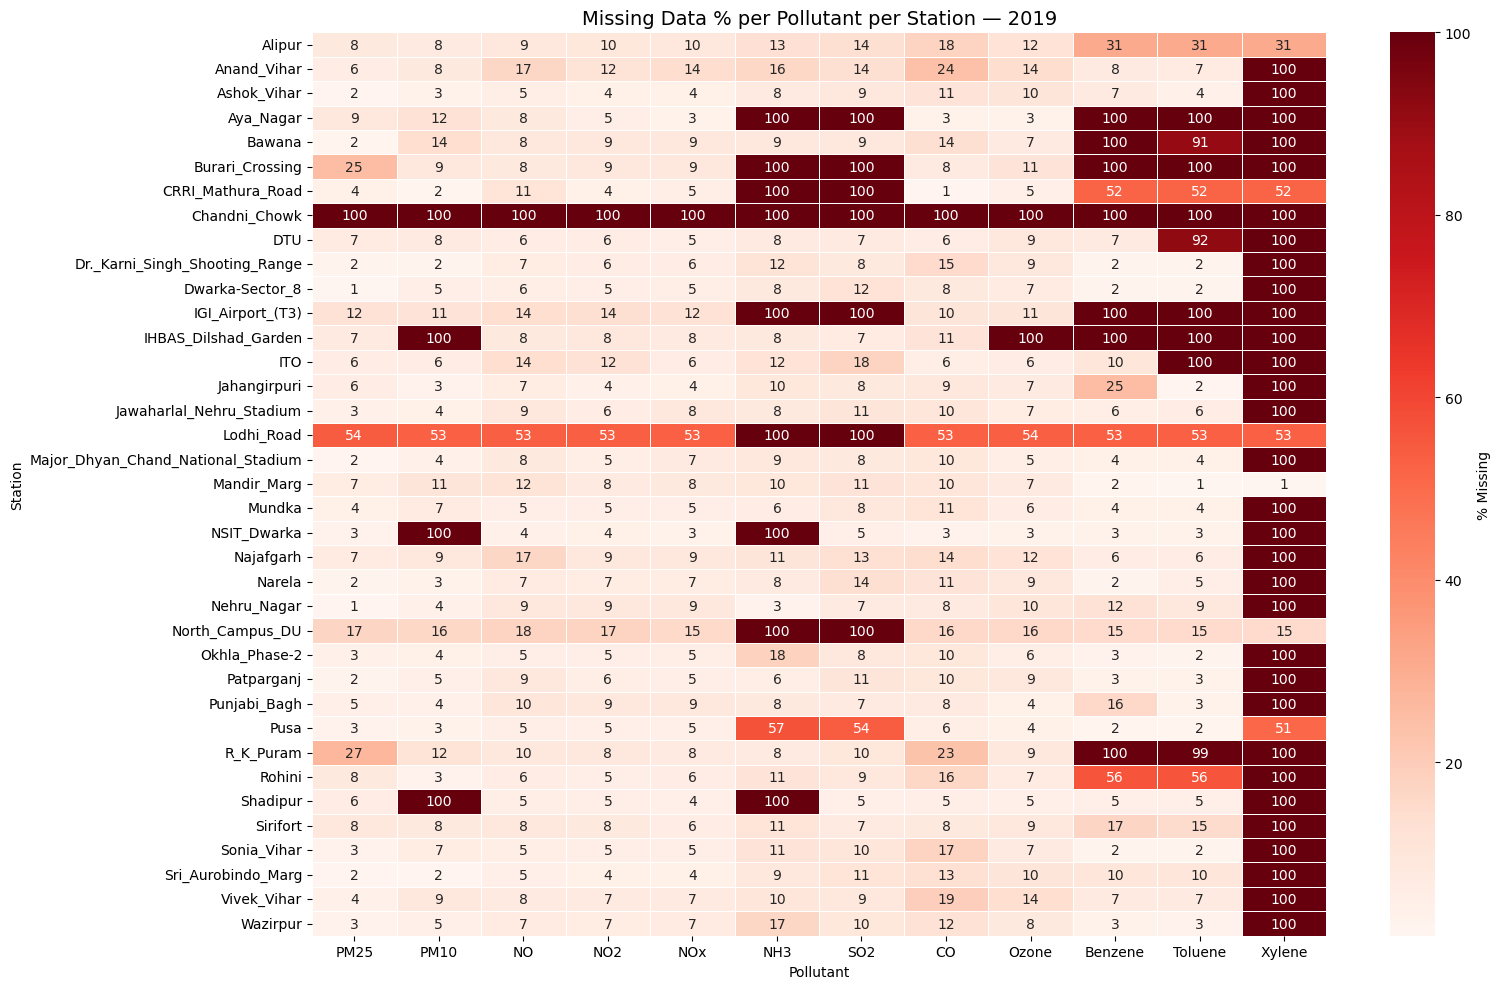

In [4]:
missing_pct = df.groupby('Station')[pollutants].apply(
    lambda x: (x.isnull().sum() / len(x) * 100).round(1)
)

plt.figure(figsize=(16, 10))
sns.heatmap(missing_pct, cmap='Reds', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': '% Missing'})
plt.title('Missing Data % per Pollutant per Station — 2019', fontsize=14)
plt.xlabel('Pollutant')
plt.ylabel('Station')
plt.tight_layout()
plt.savefig('../figures/02_missing_pct_station_variable.png', dpi=150, bbox_inches='tight')
plt.show()

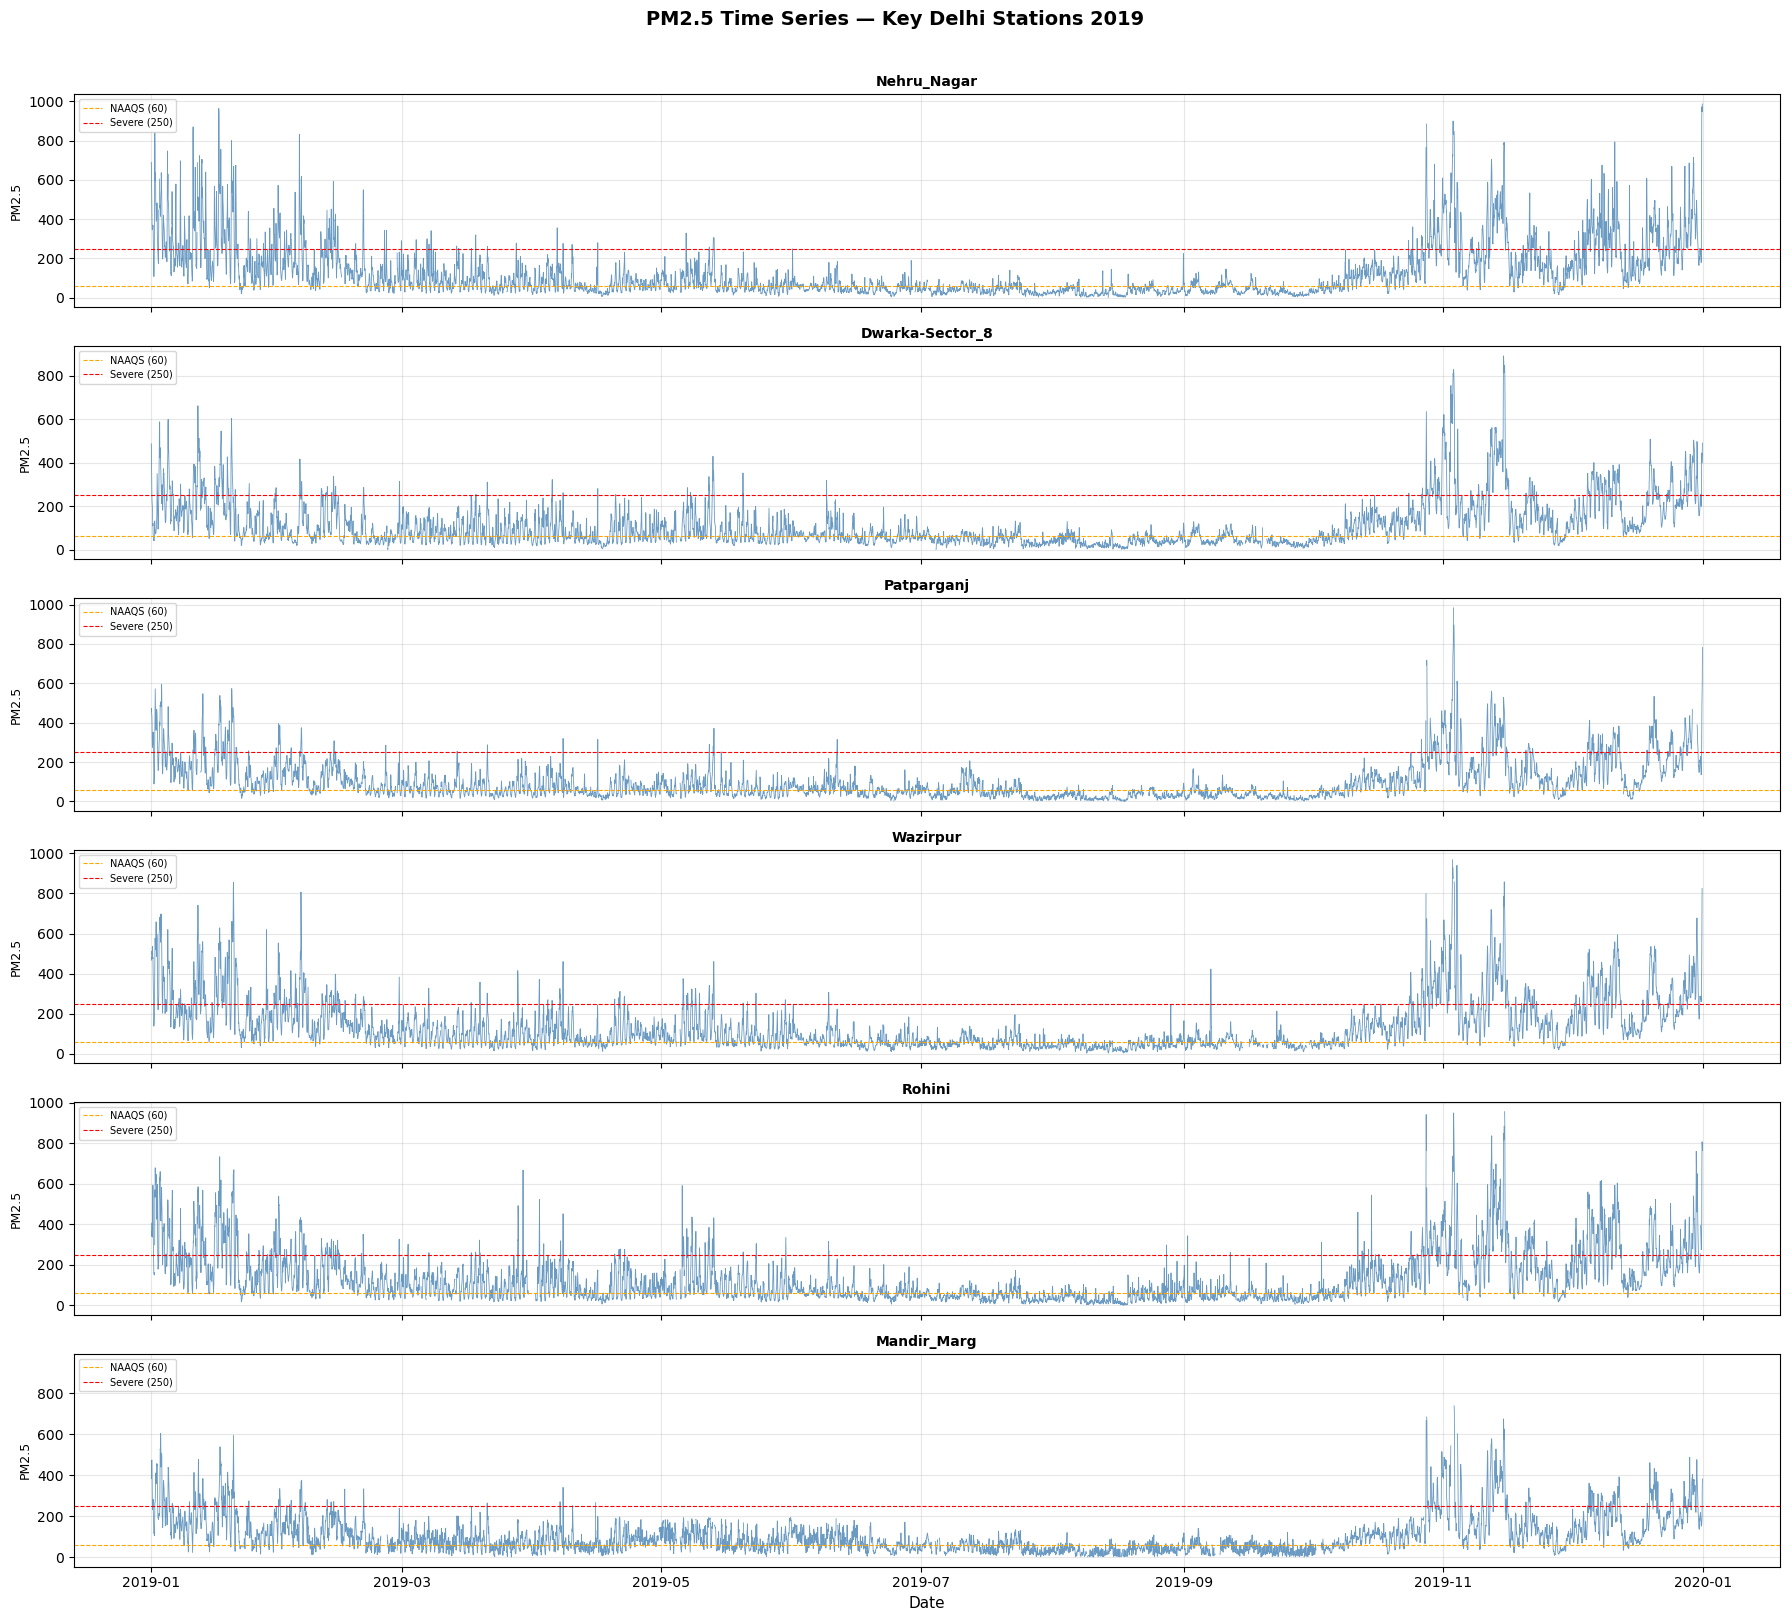

Saved!


In [5]:
# Pick top 6 clean stations for visualization
stations_to_plot = ['Nehru_Nagar', 'Dwarka-Sector_8', 'Patparganj', 
                    'Wazirpur', 'Rohini', 'Mandir_Marg']

fig, axes = plt.subplots(6, 1, figsize=(18, 16), sharex=True)

for ax, station in zip(axes, stations_to_plot):
    data = df[df['Station'] == station][['Timestamp', 'PM25']].copy()
    data = data.set_index('Timestamp').resample('1H').mean()  # hourly average for clarity
    ax.plot(data.index, data['PM25'], linewidth=0.6, color='steelblue', alpha=0.8)
    ax.set_ylabel('PM2.5', fontsize=9)
    ax.set_title(station, fontsize=10, fontweight='bold')
    ax.axhline(60, color='orange', linestyle='--', linewidth=0.8, label='NAAQS (60)')
    ax.axhline(250, color='red', linestyle='--', linewidth=0.8, label='Severe (250)')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
fig.suptitle('PM2.5 Time Series — Key Delhi Stations 2019', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/03_pm25_timeseries_all_stations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

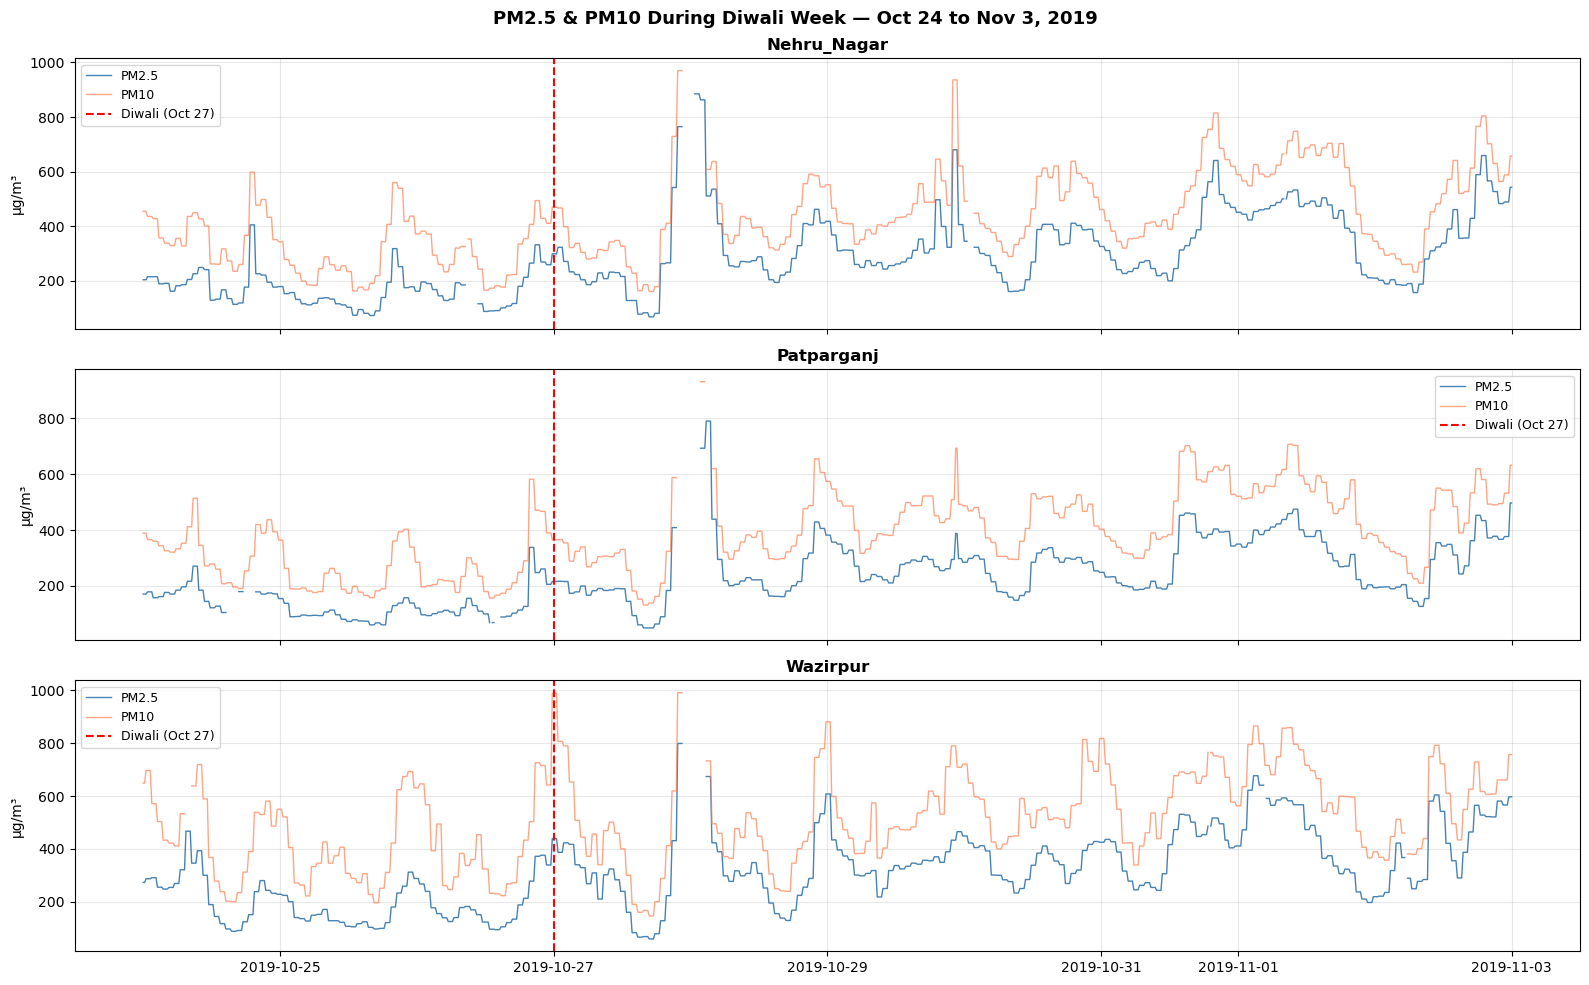

Saved!


In [6]:
# Diwali was Oct 27, 2019 — zoom in Oct 24 to Nov 3
diwali_start = '2019-10-24'
diwali_end = '2019-11-03'

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, station in zip(axes, ['Nehru_Nagar', 'Patparganj', 'Wazirpur']):
    data = df[(df['Station'] == station) & 
              (df['Timestamp'] >= diwali_start) & 
              (df['Timestamp'] <= diwali_end)][['Timestamp', 'PM25', 'PM10']]
    ax.plot(data['Timestamp'], data['PM25'], label='PM2.5', color='steelblue', linewidth=1)
    ax.plot(data['Timestamp'], data['PM10'], label='PM10', color='coral', linewidth=1, alpha=0.7)
    ax.axvline(pd.Timestamp('2019-10-27'), color='red', linestyle='--', linewidth=1.5, label='Diwali (Oct 27)')
    ax.set_title(station, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('µg/m³')

fig.suptitle('PM2.5 & PM10 During Diwali Week — Oct 24 to Nov 3, 2019', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/04_diwali_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

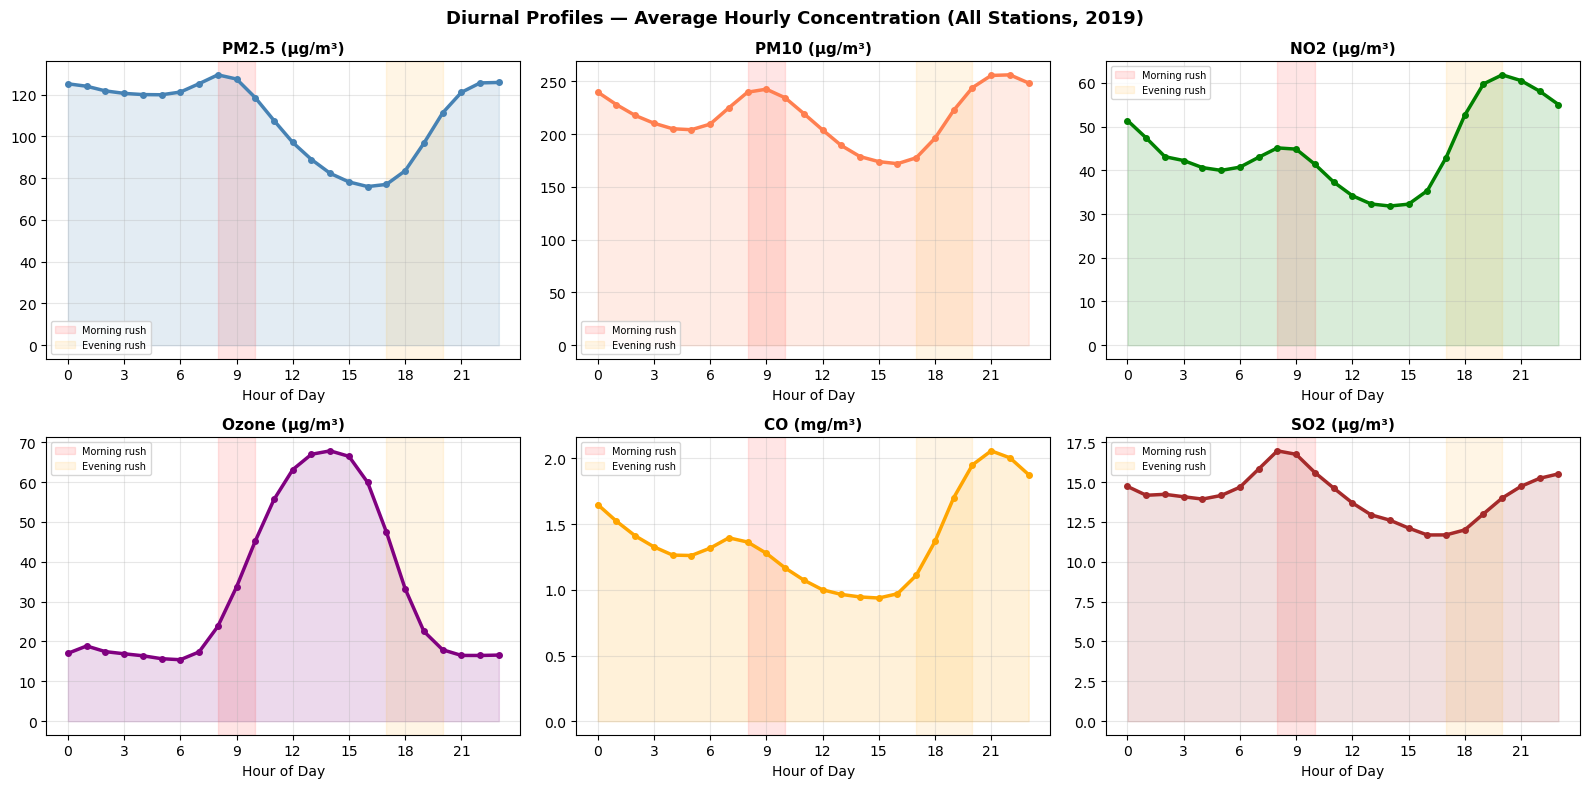

Saved!


In [7]:
# Average concentration by hour of day for key pollutants
# Use all stations combined
diurnal = df.groupby('Hour')[['PM25', 'PM10', 'NO2', 'Ozone', 'CO', 'SO2']].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = ['steelblue', 'coral', 'green', 'purple', 'orange', 'brown']
pollutant_labels = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 
                    'Ozone (µg/m³)', 'CO (mg/m³)', 'SO2 (µg/m³)']

for ax, col, label, color in zip(axes, diurnal.columns, pollutant_labels, colors):
    ax.plot(diurnal.index, diurnal[col], color=color, linewidth=2.5, marker='o', markersize=4)
    ax.fill_between(diurnal.index, diurnal[col], alpha=0.15, color=color)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_xlabel('Hour of Day')
    ax.set_xticks(range(0, 24, 3))
    ax.axvspan(8, 10, alpha=0.1, color='red', label='Morning rush')
    ax.axvspan(17, 20, alpha=0.1, color='orange', label='Evening rush')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('Diurnal Profiles — Average Hourly Concentration (All Stations, 2019)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/05_diurnal_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

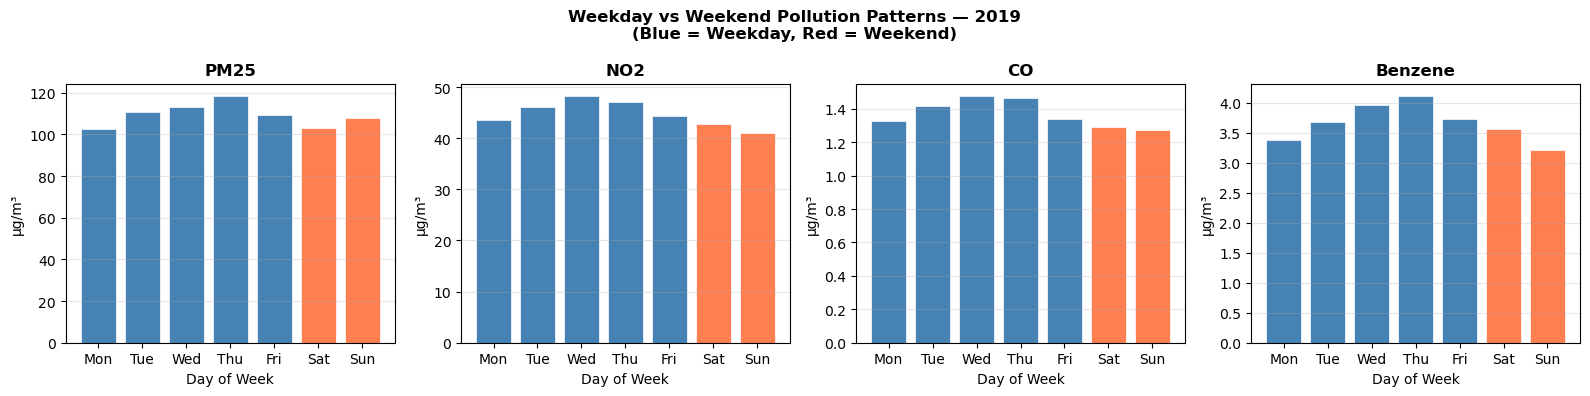

Saved!


In [8]:
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow = df.groupby('DayOfWeek')[['PM25', 'NO2', 'CO', 'Benzene']].mean()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, ['PM25', 'NO2', 'CO', 'Benzene']):
    colors_dow = ['steelblue']*5 + ['coral']*2  # weekdays blue, weekends red
    ax.bar(days, dow[col], color=colors_dow, edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('µg/m³')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xlabel('Day of Week')

fig.suptitle('Weekday vs Weekend Pollution Patterns — 2019\n(Blue = Weekday, Red = Weekend)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/06_day_of_week.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

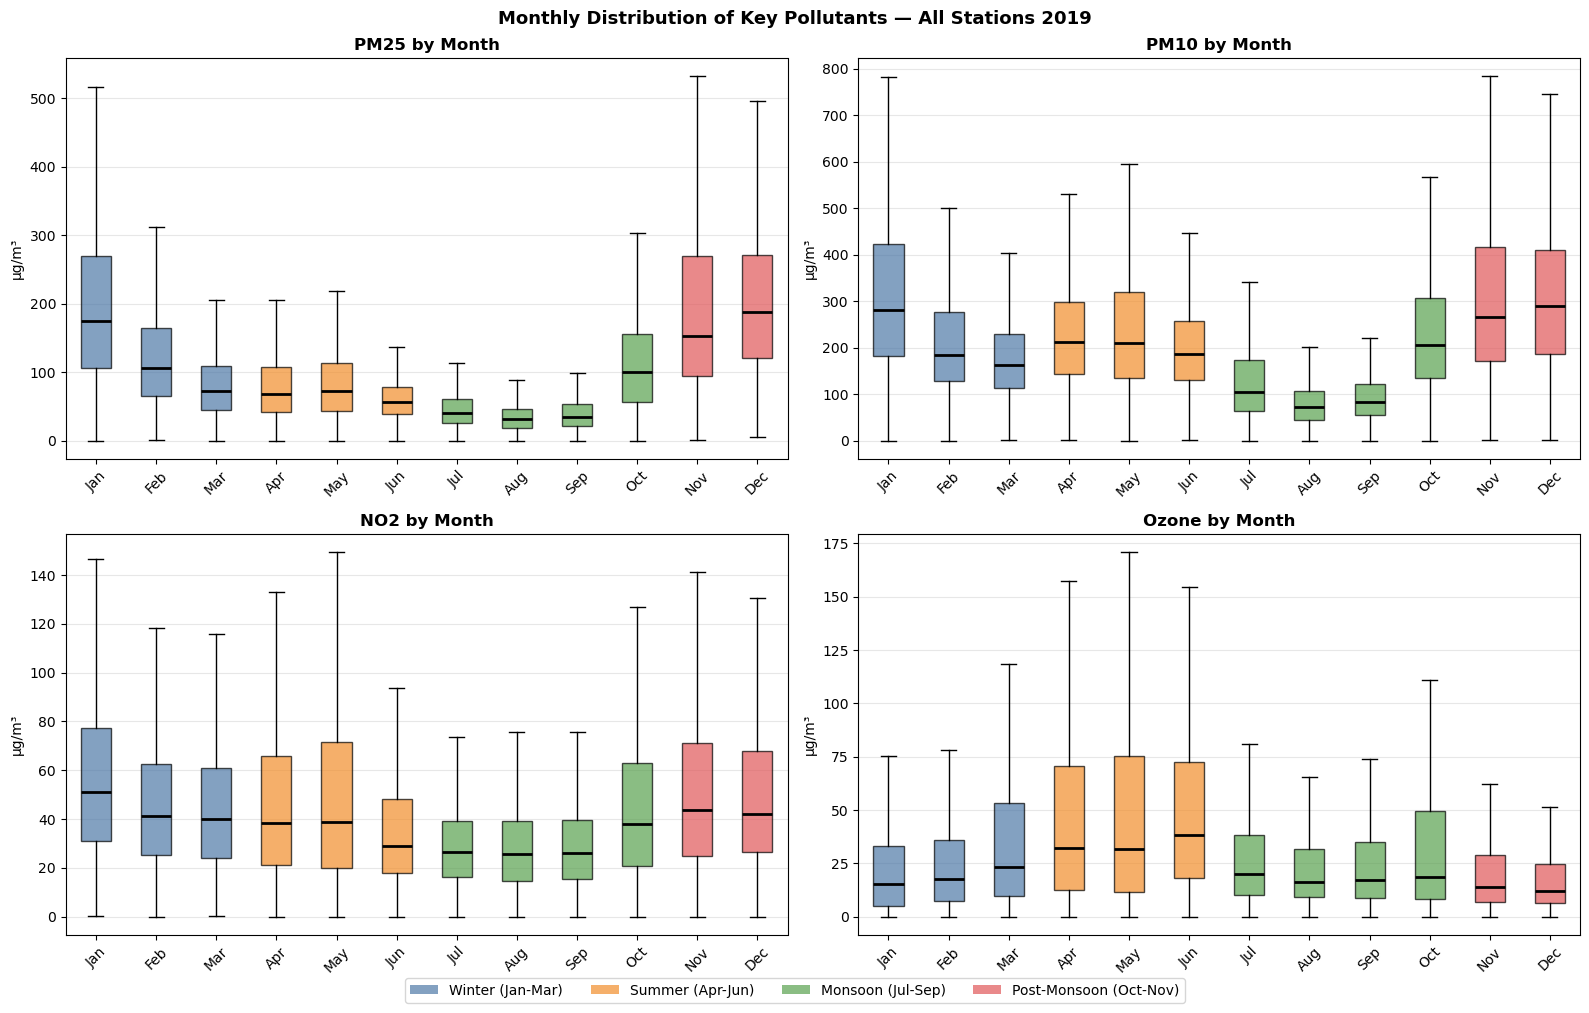

Saved!


In [9]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, ['PM25', 'PM10', 'NO2', 'Ozone']):
    data_by_month = [df[df['Month']==m][col].dropna().values for m in range(1,13)]
    bp = ax.boxplot(data_by_month, labels=month_names, patch_artist=True,
                    showfliers=False, medianprops=dict(color='black', linewidth=2))
    # Color by season
    season_colors = ['#4e79a7','#4e79a7','#4e79a7',  # Winter - blue
                     '#f28e2b','#f28e2b','#f28e2b',  # Summer - orange
                     '#59a14f','#59a14f','#59a14f','#59a14f',  # Monsoon - green
                     '#e15759','#e15759']             # Post-monsoon - red
    for patch, color in zip(bp['boxes'], season_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f'{col} by Month', fontweight='bold', fontsize=12)
    ax.set_ylabel('µg/m³')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)

# Add season legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4e79a7', alpha=0.7, label='Winter (Jan-Mar)'),
                   Patch(facecolor='#f28e2b', alpha=0.7, label='Summer (Apr-Jun)'),
                   Patch(facecolor='#59a14f', alpha=0.7, label='Monsoon (Jul-Sep)'),
                   Patch(facecolor='#e15759', alpha=0.7, label='Post-Monsoon (Oct-Nov)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10, 
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Monthly Distribution of Key Pollutants — All Stations 2019', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/07_seasonal_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

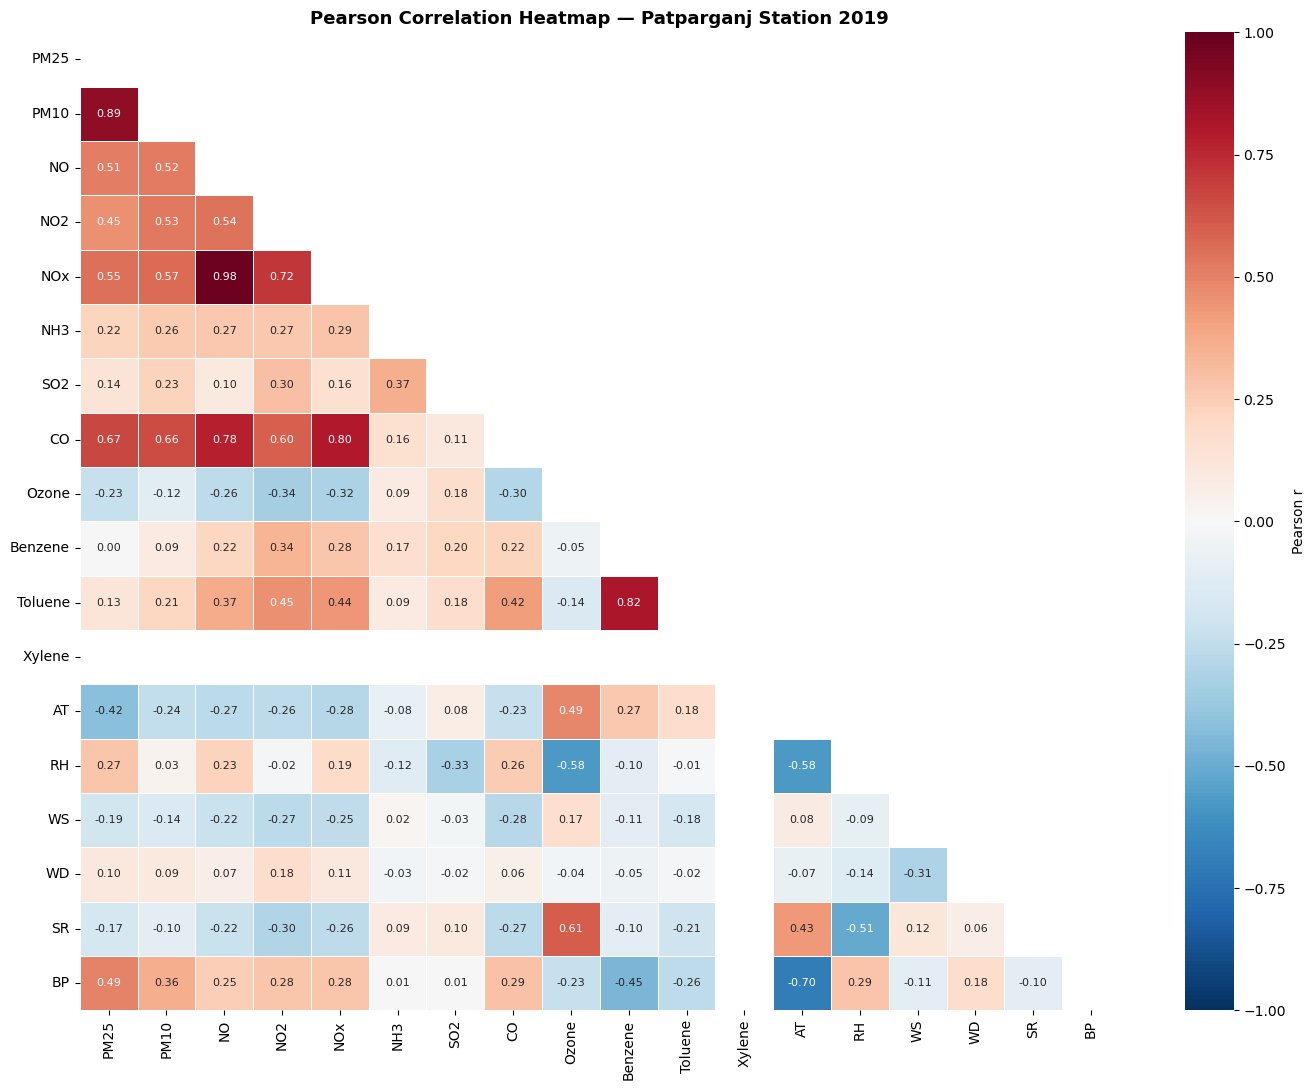

Saved!


In [13]:
corr_cols = ['PM25','PM10','NO','NO2','NOx','NH3','SO2',
             'CO','Ozone','Benzene','Toluene','Xylene','AT','RH','WS','WD','SR','BP']

# Use one good station for clean correlation
df_corr = df[df['Station'] == 'Patparganj'][corr_cols]

# Pearson correlation
corr_matrix = df_corr.corr(method='pearson')

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8},
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Pearson Correlation Heatmap — Patparganj Station 2019', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

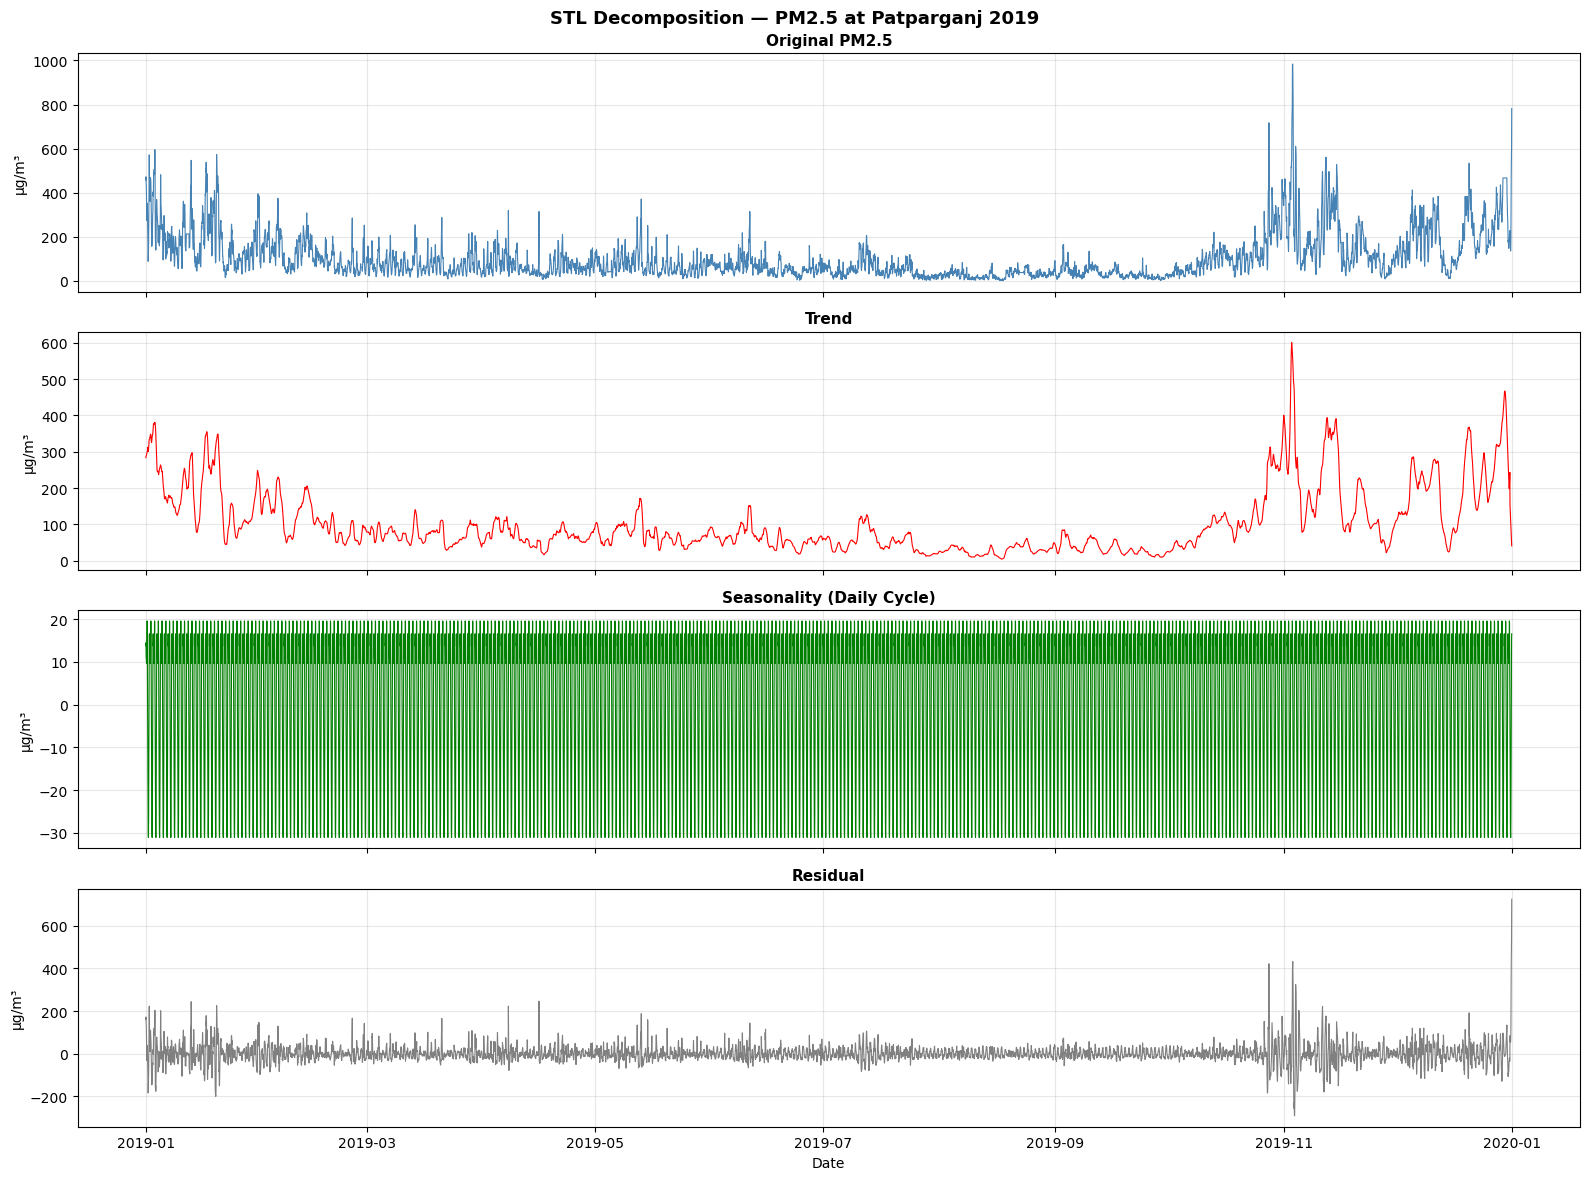

Saved!


In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use Patparganj PM2.5, resample to hourly
ts = df[df['Station']=='Patparganj'][['Timestamp','PM25']].copy()
ts = ts.set_index('Timestamp').resample('1H').mean()
ts = ts.ffill().bfill()  # fill small gaps

# STL decomposition - period=24 (daily cycle)
decomp = seasonal_decompose(ts['PM25'], model='additive', period=24, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
components = [ts['PM25'], decomp.trend, decomp.seasonal, decomp.resid]
titles = ['Original PM2.5', 'Trend', 'Seasonality (Daily Cycle)', 'Residual']
colors = ['steelblue', 'red', 'green', 'gray']

for ax, data, title, color in zip(axes, components, titles, colors):
    ax.plot(data.index, data.values, color=color, linewidth=0.8)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('µg/m³')

axes[-1].set_xlabel('Date')
fig.suptitle('STL Decomposition — PM2.5 at Patparganj 2019', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/09_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [15]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

variables_to_test = ['PM25', 'NO2', 'Ozone', 'CO']
ts_data = df[df['Station']=='Patparganj'].set_index('Timestamp')

ts_data = ts_data.resample('1H').mean(numeric_only=True).ffill()

results = []
for var in variables_to_test:
    series = ts_data[var].dropna()
    
    # ADF test
    adf_result = adfuller(series, autolag='AIC')
    adf_stat, adf_p = adf_result[0], adf_result[1]
    
    # KPSS test
    kpss_result = kpss(series, regression='c', nlags='auto')
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    
    results.append({
        'Variable': var,
        'ADF Statistic': round(adf_stat, 4),
        'ADF p-value': round(adf_p, 4),
        'ADF Result': 'Stationary ✓' if adf_p < 0.05 else 'Non-stationary ✗',
        'KPSS Statistic': round(kpss_stat, 4),
        'KPSS p-value': round(kpss_p, 4),
        'KPSS Result': 'Stationary ✓' if kpss_p > 0.05 else 'Non-stationary ✗'
    })

results_df = pd.DataFrame(results)
print("=== STATIONARITY TEST RESULTS ===\n")
print(results_df.to_string(index=False))
results_df.to_csv('../figures/10_stationarity_results.csv', index=False)
print("\nSaved!")


C:\Users\Krishna Gupta\AppData\Local\Temp\ipykernel_47700\3876693690.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')
C:\Users\Krishna Gupta\AppData\Local\Temp\ipykernel_47700\3876693690.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')
C:\Users\Krishna Gupta\AppData\Local\Temp\ipykernel_47700\3876693690.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


=== STATIONARITY TEST RESULTS ===

Variable  ADF Statistic  ADF p-value   ADF Result  KPSS Statistic  KPSS p-value      KPSS Result
    PM25        -5.2539          0.0 Stationary ✓          2.1074          0.01 Non-stationary ✗
     NO2        -7.0267          0.0 Stationary ✓          2.0761          0.01 Non-stationary ✗
   Ozone        -8.4945          0.0 Stationary ✓          3.6411          0.01 Non-stationary ✗
      CO        -7.7311          0.0 Stationary ✓          2.0596          0.01 Non-stationary ✗

Saved!


C:\Users\Krishna Gupta\AppData\Local\Temp\ipykernel_47700\3876693690.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series, regression='c', nlags='auto')


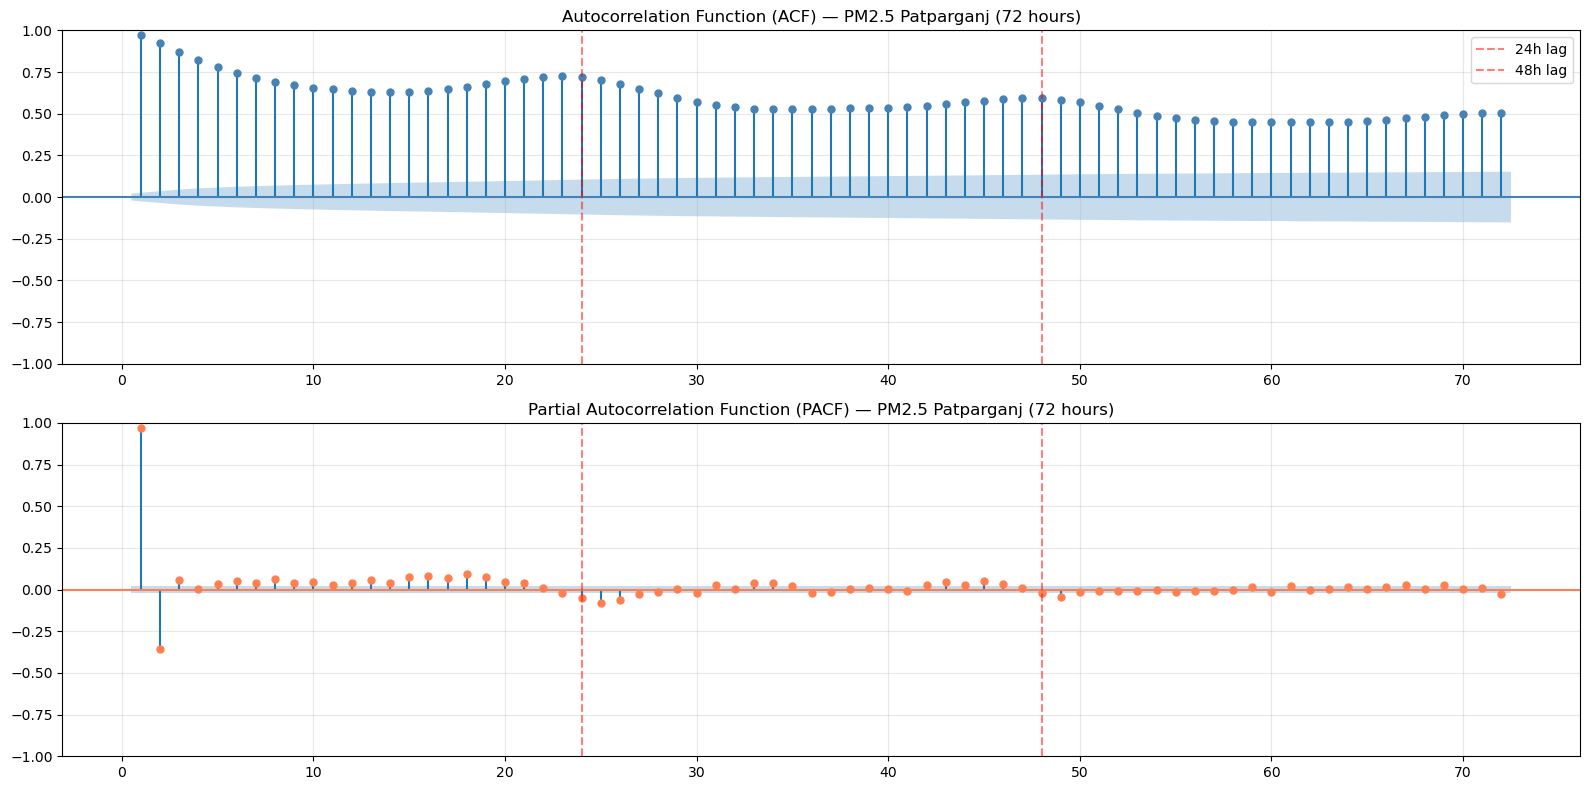

Saved!


In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ts_hourly = df[df['Station']=='Patparganj'][['Timestamp','PM25']].copy()
ts_hourly = ts_hourly.set_index('Timestamp').resample('1H').mean().ffill()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(ts_hourly['PM25'], lags=72, ax=axes[0], 
         title='Autocorrelation Function (ACF) — PM2.5 Patparganj (72 hours)',
         color='steelblue', zero=False)
plot_pacf(ts_hourly['PM25'], lags=72, ax=axes[1],
          title='Partial Autocorrelation Function (PACF) — PM2.5 Patparganj (72 hours)',
          color='coral', zero=False, method='ywm')

axes[0].axvline(24, color='red', linestyle='--', alpha=0.5, label='24h lag')
axes[0].axvline(48, color='red', linestyle='--', alpha=0.5, label='48h lag')
axes[1].axvline(24, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(48, color='red', linestyle='--', alpha=0.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/11_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

  Using cached windrose-1.9.2-py3-none-any.whl.metadata (5.2 kB)
Using cached windrose-1.9.2-py3-none-any.whl (20 kB)


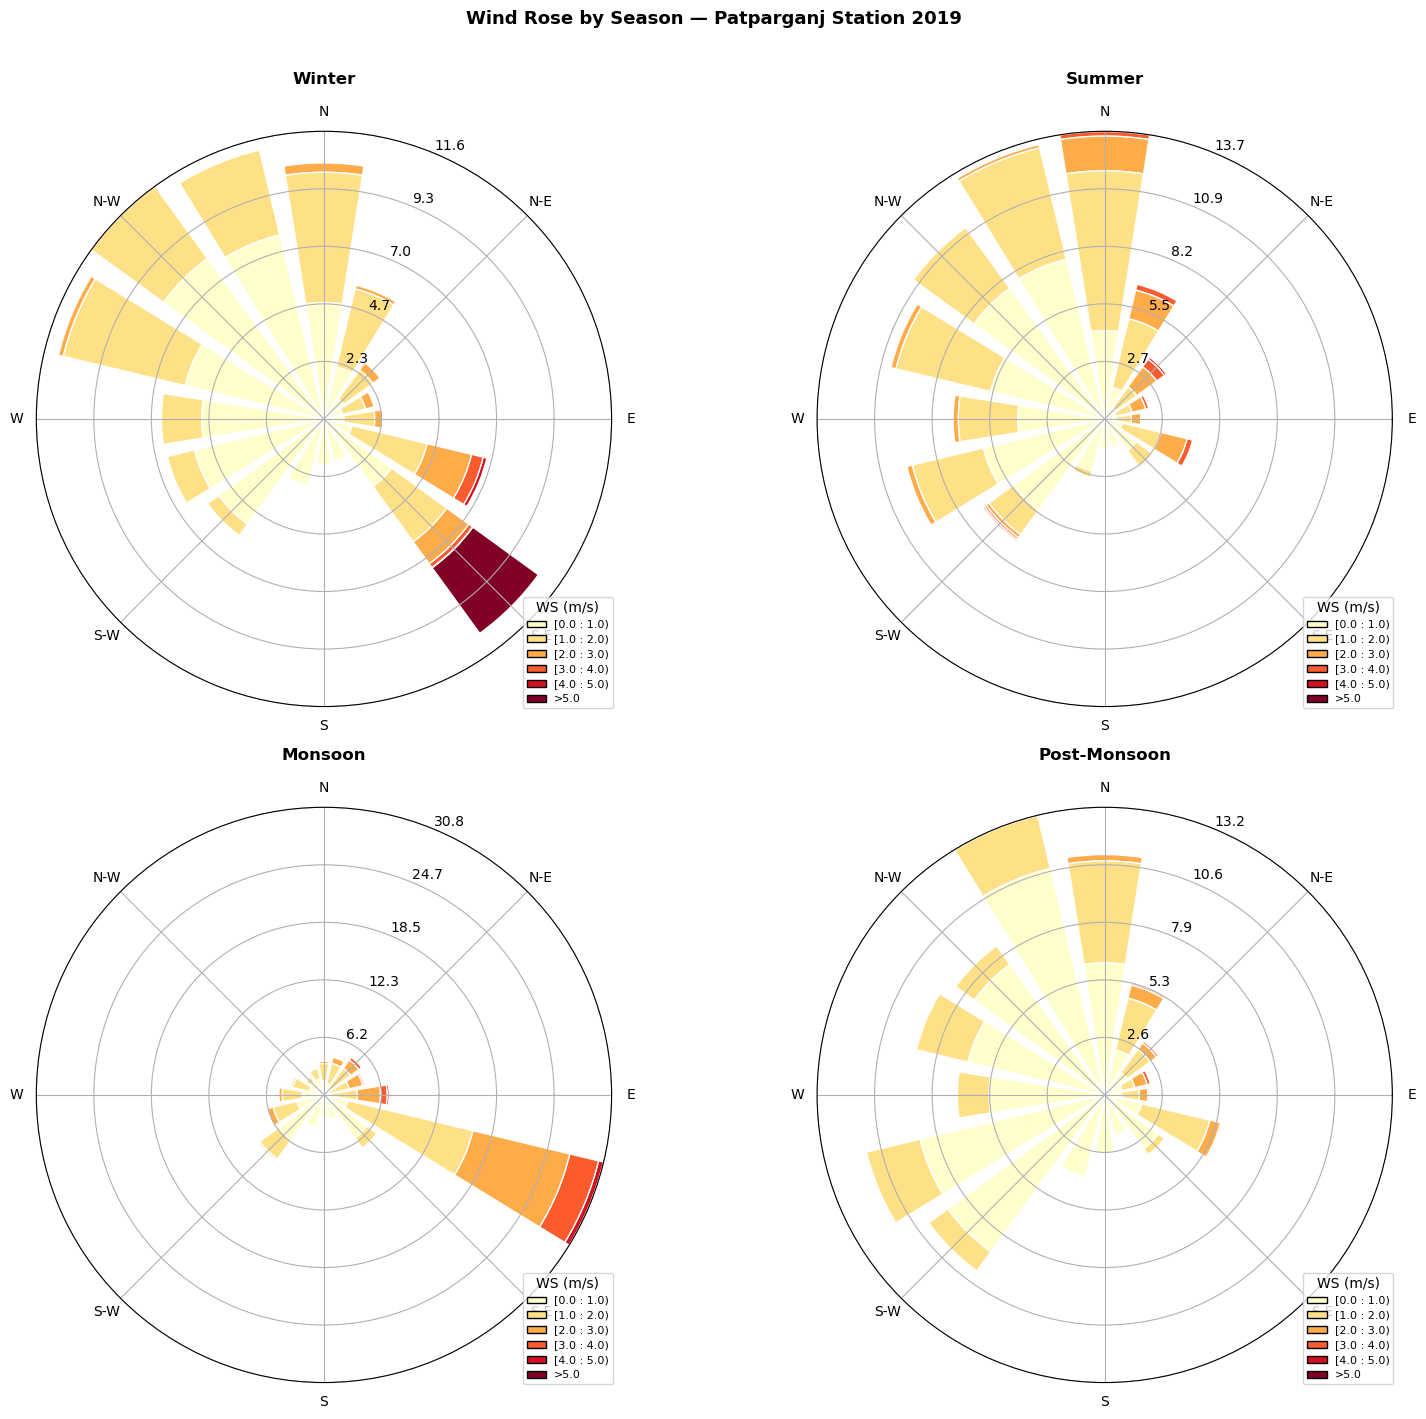

Saved!


In [18]:
!pip install windrose
from windrose import WindroseAxes

# Use Patparganj, filter valid wind data
wr_data = df[df['Station']=='Patparganj'][['WS','WD','Season']].dropna()

seasons = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
fig = plt.figure(figsize=(16, 14))

for i, season in enumerate(seasons):
    ax = fig.add_subplot(2, 2, i+1, projection='windrose')
    data = wr_data[wr_data['Season']==season]
    ax.bar(data['WD'], data['WS'], normed=True, opening=0.8,
           bins=[0, 1, 2, 3, 4, 5], cmap=plt.cm.YlOrRd, edgecolor='white')
    ax.set_title(f'{season}', fontsize=12, fontweight='bold', pad=15)
    ax.set_legend(title='WS (m/s)', loc='lower right', fontsize=7)

fig.suptitle('Wind Rose by Season — Patparganj Station 2019', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/12_wind_rose.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

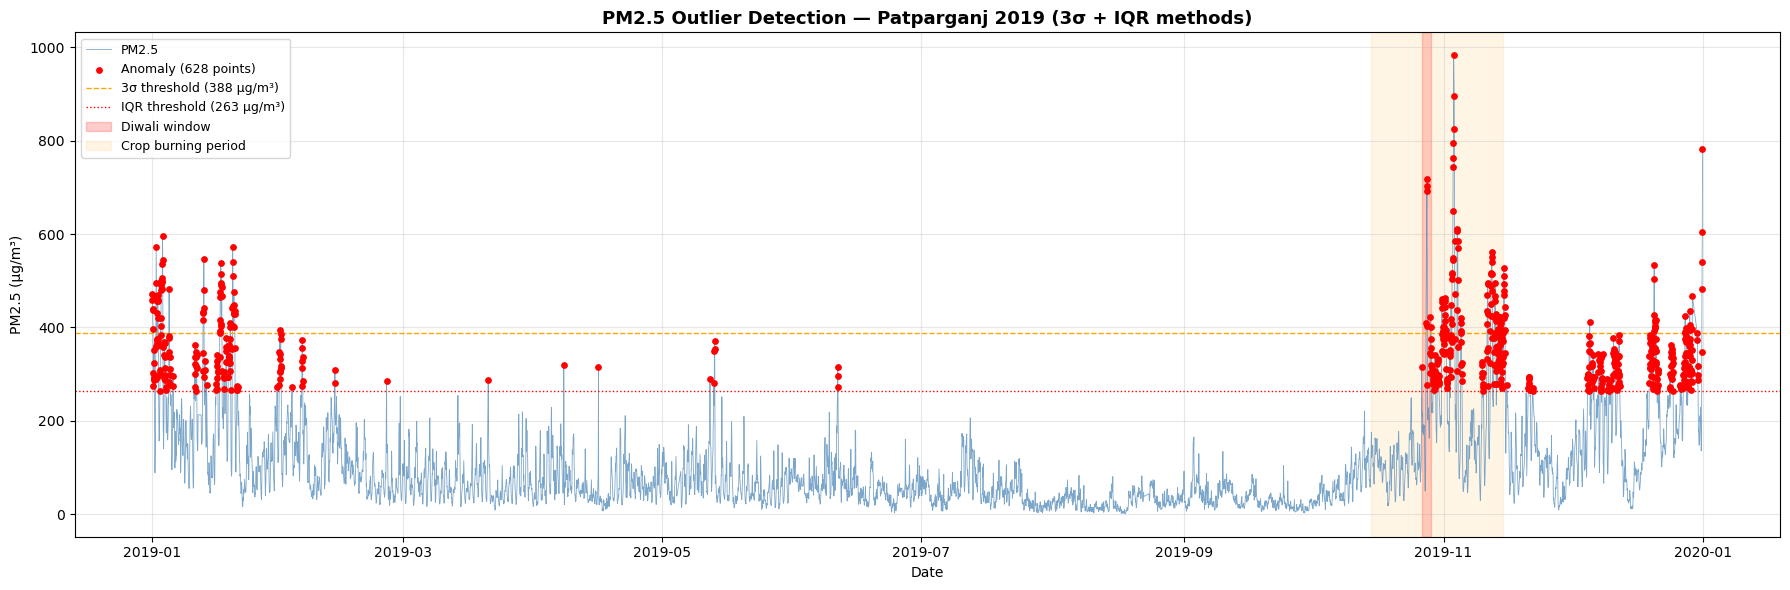


Total anomalous hours: 628
% of data flagged: 7.3%


In [19]:
# IQR and 3-sigma flagging on PM2.5
ts_plot = df[df['Station']=='Patparganj'][['Timestamp','PM25']].copy()
ts_plot = ts_plot.set_index('Timestamp').resample('1H').mean().reset_index()
ts_plot = ts_plot.dropna()

# 3-sigma method
mean_val = ts_plot['PM25'].mean()
std_val = ts_plot['PM25'].std()
ts_plot['zscore_flag'] = ts_plot['PM25'] > (mean_val + 3*std_val)

# IQR method
Q1 = ts_plot['PM25'].quantile(0.25)
Q3 = ts_plot['PM25'].quantile(0.75)
IQR = Q3 - Q1
ts_plot['iqr_flag'] = ts_plot['PM25'] > (Q3 + 1.5*IQR)
ts_plot['any_flag'] = ts_plot['zscore_flag'] | ts_plot['iqr_flag']

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(ts_plot['Timestamp'], ts_plot['PM25'], 
        color='steelblue', linewidth=0.6, alpha=0.7, label='PM2.5')
ax.scatter(ts_plot[ts_plot['any_flag']]['Timestamp'],
           ts_plot[ts_plot['any_flag']]['PM25'],
           color='red', s=15, zorder=5, label=f'Anomaly ({ts_plot["any_flag"].sum()} points)')
ax.axhline(mean_val + 3*std_val, color='orange', linestyle='--', 
           linewidth=1, label=f'3σ threshold ({mean_val+3*std_val:.0f} µg/m³)')
ax.axhline(Q3 + 1.5*IQR, color='red', linestyle=':', 
           linewidth=1, label=f'IQR threshold ({Q3+1.5*IQR:.0f} µg/m³)')

# Annotate Diwali
ax.axvspan(pd.Timestamp('2019-10-27'), pd.Timestamp('2019-10-29'), 
           alpha=0.2, color='red', label='Diwali window')
ax.axvspan(pd.Timestamp('2019-10-15'), pd.Timestamp('2019-11-15'),
           alpha=0.1, color='orange', label='Crop burning period')

ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('PM2.5 Outlier Detection — Patparganj 2019 (3σ + IQR methods)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/13_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTotal anomalous hours: {ts_plot['any_flag'].sum()}")
print(f"% of data flagged: {ts_plot['any_flag'].mean()*100:.1f}%")